### Import Libraries

In [15]:
import numpy as np
import pickle
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,LSTM,Embedding,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

### project paths

In [16]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR     = BASE_DIR / "data"
FEATURES_DIR = DATA_DIR / "dl_features"
MODELS_DIR   = FEATURES_DIR

print("BASE_DIR      :", BASE_DIR)
print("FEATURES_DIR  :", FEATURES_DIR)

BASE_DIR      : c:\Users\mereh\nlp-fake-news-detector-transformers
FEATURES_DIR  : c:\Users\mereh\nlp-fake-news-detector-transformers\data\dl_features


### Load preprocessed features

In [17]:
def load_features():
    print("Loading preprocessed features...")

    X_train = np.load(FEATURES_DIR / "X_train_pad.npy")
    X_val   = np.load(FEATURES_DIR / "X_val_pad.npy")
    X_test  = np.load(FEATURES_DIR / "X_test_pad.npy")

    y_train = np.load(FEATURES_DIR / "y_train.npy")
    y_val   = np.load(FEATURES_DIR / "y_val.npy")
    y_test  = np.load(FEATURES_DIR / "y_test.npy")

    with open(FEATURES_DIR / "meta.pkl", "rb") as f:
        meta = pickle.load(f)

    with open(FEATURES_DIR / "tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)

    print(f"  X_train shape : {X_train.shape}")
    print(f"  X_val   shape : {X_val.shape}")
    print(f"  X_test  shape : {X_test.shape}")
    print(f"  max_len       : {meta['max_len']}")
    print(f"  max_words     : {meta['max_words']}")
    print(f"  Vocab size    : {len(tokenizer.word_index)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, meta, tokenizer

In [18]:
X_train, X_val, X_test, y_train, y_val, y_test, meta, tokenizer = load_features()

Loading preprocessed features...


  X_train shape : (963423, 20)
  X_val   shape : (222329, 20)
  X_test  shape : (296438, 20)
  max_len       : 20
  max_words     : 20000
  Vocab size    : 295251


In [19]:
max_words = meta['max_words']
max_len = meta['max_len']

### build LSTM model

In [20]:
model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim = max_words,
        output_dim = 128,
    ),
    
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")

])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,633 (9.97 MB)

 Trainable params: 2,613,633 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

### Compile model

In [22]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = Adam(learning_rate=0.001),
    metrics = ["accuracy"]
)

### Early stopping

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

### Train model

In [ ]:
history = model.fit(
    X_train, 
    y_train,
    validation_data = (X_val, y_val),
    epochs = 10,
    batch_size = 128,
    callbacks=[early_stop]
)

Epoch 1/10
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 335s 44ms/step - accuracy: 0.7798 - loss: 0.4632 - val_accuracy: 0.7948 - val_loss: 0.4396
Epoch 2/10
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 335s 44ms/step - accuracy: 0.8050 - loss: 0.4229 - val_accuracy: 0.7981 - val_loss: 0.4348
Epoch 3/10
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 181s 24ms/step - accuracy: 0.8174 - loss: 0.4007 - val_accuracy: 0.7980 - val_loss: 0.4367
Epoch 4/10
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 203s 27ms/step - accuracy: 0.8297 - loss: 0.3769 - val_accuracy: 0.7947 - val_loss: 0.4480


### Evaluate model

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

9264/9264 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.7970 - loss: 0.4350
Test Loss: 0.4350
Test Accuracy: 0.7970


### Plot accuracy & loss

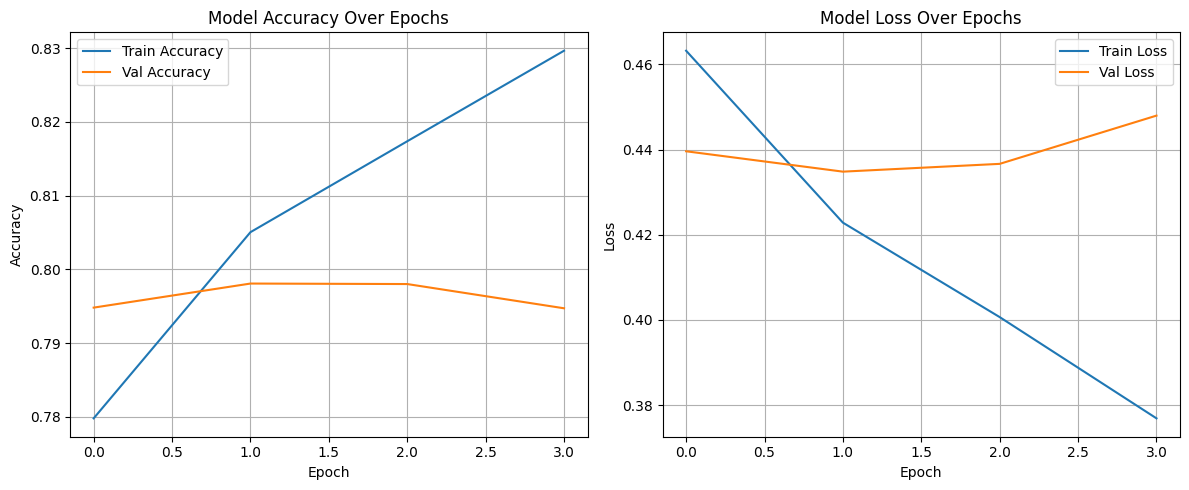

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()